#1.-Intalación y implementacion

Este bloque instala y carga las librerías necesarias. Se usa MedMNIST para descargar PathMNIST, PyTorch para la CNN, torchvision para ResNet18 pre-entrenada, y sklearn para calcular métricas.

In [ ]:
!pip install -q medmnist torch torchvision scikit-learn seaborn tqdm

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import medmnist
from medmnist import INFO

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.6 MB/s eta 0:00:00


#2.-Configuracion reproducioble del experimento

Este bloque fija la semilla para que el experimento sea reproducible. También define que usaremos PathMNIST, resolución 28x28, y detecta automáticamente si el cuadernillo puede usar GPU.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_FLAG = "pathmnist"
SIZE = 28
BATCH_SIZE = 256
NUM_WORKERS = 2

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

n_classes = len(info["label"])
class_names = [info["label"][str(i)] for i in range(n_classes)]

print("Dispositivo:", DEVICE)
print("Dataset:", DATA_FLAG)
print("Resolución:", SIZE, "x", SIZE)
print("Número de clases:", n_classes)
print("Clases:", class_names)

Dispositivo: cpu
Dataset: pathmnist
Resolución: 28 x 28
Número de clases: 9
Clases: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']


#3.-Definicion formal de hold-out

Este bloque deja documentado el diseño experimental. Training se usa para aprender, validation para decidir cuál época/modelo funciona mejor, y test queda reservado para la evaluación final.

Esto es exactamente el hold-out: dividir los datos en subconjuntos separados. En este trabajo no conviene hacer train_test_split manual, porque PathMNIST ya viene con particiones oficiales.

In [ ]:
split_sizes = info["n_samples"]

holdout_df = pd.DataFrame({
    "Conjunto": ["Training", "Validation", "Test"],
    "Split oficial MedMNIST": ["train", "val", "test"],
    "Cantidad de imágenes": [
        split_sizes["train"],
        split_sizes["val"],
        split_sizes["test"]
    ],
    "Uso experimental": [
        "Entrenar los pesos del modelo",
        "Elegir el mejor modelo durante el entrenamiento",
        "Evaluar el rendimiento final una sola vez"
    ]
})

display(holdout_df)

,Conjunto,Split oficial MedMNIST,Cantidad de imágenes,Uso experimental
0,Training,train,89996,Entrenar los pesos del modelo
1,Validation,val,10004,Elegir el mejor modelo durante el entrenamiento
2,Test,test,7180,Evaluar el rendimiento final una sola vez


# 4.-Trasformacion y carga de datos

Este bloque carga los tres conjuntos oficiales. Al entrenamiento se le aplican aumentos leves de datos: giros, rotaciones y volteos. A validación y test no se les aplica aumento, porque esos conjuntos deben medir el rendimiento real del modelo.

La normalización usada es la de ImageNet porque el modelo ResNet18 viene pre-entrenado con ImageNet. Esto es importante para que la entrada tenga una escala compatible con los pesos pre-entrenados.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = DataClass(
    split="train",
    transform=train_transform,
    download=True,
    size=SIZE
)

val_dataset = DataClass(
    split="val",
    transform=val_test_transform,
    download=True,
    size=SIZE
)

test_dataset = DataClass(
    split="test",
    transform=val_test_transform,
    download=True,
    size=SIZE
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 206M/206M [00:08<00:00, 24.9MB/s]


Train: 89996
Validation: 10004
Test: 7180


# 5.-Dataloaders

Este bloque prepara los datos para entrenamiento por lotes. En vez de pasar las 89.996 imágenes de una vez, el modelo procesa grupos de 256 imágenes.

Los resultados dan esto:(Despues borramos esto, es para que cuando lo lean lo entiendan mas)

Forma del batch de imágenes: torch.Size([256, 3, 28, 28])

Eso significa: 256 imágenes, 3 canales RGB, alto 28 y ancho 28.

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Forma del batch de imágenes:", images.shape)
print("Forma del batch de etiquetas:", labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forma del batch de imágenes: torch.Size([256, 3, 28, 28])
Forma del batch de etiquetas: torch.Size([256, 1])


#6.- Definción de metricas de validación

Aquí quedan definidas más de dos métricas, así que se cumple la rúbrica. Las más importantes para defender en la presentación son Balanced Accuracy y Macro-F1, porque PathMNIST es multiclase y no conviene depender solo del accuracy.

Accuracy puede verse alto aunque el modelo falle en clases minoritarias. Macro-F1 obliga a mirar el rendimiento promedio por clase.

In [ ]:
def calcular_metricas(y_true, y_pred):
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }
    return metricas


metricas_definidas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ],
    "Uso en el proyecto": [
        "Métrica general de acierto global",
        "Métrica principal para compensar diferencias entre clases",
        "Métrica principal para evaluar desempeño promedio por clase",
        "Métrica complementaria ponderada por cantidad de muestras"
    ]
})

display(metricas_definidas)

,Métrica,Uso en el proyecto
0,Accuracy,Métrica general de acierto global
1,Balanced Accuracy,Métrica principal para compensar diferencias e...
2,Macro-F1,Métrica principal para evaluar desempeño prome...
3,Weighted-F1,Métrica complementaria ponderada por cantidad ...


# 7.- Definción del modelo CNN pre-entrenado

Este bloque crea una ResNet18 pre-entrenada y cambia su última capa para que entregue 9 clases, que son las clases de PathMNIST.

Además, congela la mayor parte del modelo y deja entrenables solo layer4 y fc. Eso es fine-tuning parcial: aprovechas características generales ya aprendidas y ajustas la parte final al problema médico.

In [ ]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, n_classes)

for name, param in model.named_parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Modelo: ResNet18 pre-entrenada")
print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 52.2MB/s]


Modelo: ResNet18 pre-entrenada
Parámetros totales: 11181129
Parámetros entrenables: 8398345


# 8.- Función de entrenamiento

Esta función entrena el modelo una vez sobre todo el conjunto de training. Por cada batch calcula predicciones, mide el error, actualiza pesos y guarda las predicciones para calcular métricas.

La función devuelve dos cosas: la pérdida promedio de entrenamiento y las métricas de esa época.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Entrenando", leave=False):
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics

# 9.-Función de evalaución

Esta función evalúa el modelo sin modificar sus pesos. Se usa para validation en cada época y para test al final.

La diferencia clave es torch.no_grad(): le dice a PyTorch que no necesita guardar gradientes, por lo que la evaluación consume menos memoria.

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluando", leave=False):
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics, np.array(y_true), np.array(y_pred)

#10.- configuración de pérdida, optimizador y entrenamiento

Este bloque entrena la ResNet18 durante 5 épocas. En cada época se entrena con train_loader, se valida con val_loader y se guarda el mejor modelo según Macro-F1 de validación.

Usar Macro-F1 para elegir el mejor modelo es defendible, porque fuerza al modelo a rendir bien en todas las clases y no solo en las más frecuentes.

In [ ]:
EPOCHS = 5
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

history = []

best_val_macro_f1 = -1
best_model_path = "best_resnet18_pathmnist_28x28.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\nÉpoca {epoch}/{EPOCHS}")

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_metrics, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"]
    }

    history.append(row)

    print(pd.DataFrame([row]))

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Nuevo mejor modelo guardado según Macro-F1 de validación.")

history_df = pd.DataFrame(history)
display(history_df)


Época 1/5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Entrenando:   0%|          | 0/352 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluando:   0%|          | 0/40 [00:00<?, ?it/s]

...

Entrenando:   0%|          | 0/352 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluando:   0%|          | 0/40 [00:00<?, ?it/s]

   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      5    0.514884  0.456448        0.811703      0.838565   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.810942               0.837255        0.810884   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.839149           0.811244         0.837975  
Nuevo mejor modelo guardado según Macro-F1 de validación.


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,1,0.858894,0.628868,0.693053,0.775690,0.689873,0.773445,0.689474,0.774202,0.691021,0.773865
1,2,0.622692,0.538698,0.774468,0.808577,0.773107,0.806871,0.773077,0.808564,0.773812,0.808186
2,3,0.571553,0.500476,0.792969,0.816873,0.791548,0.814493,0.791588,0.814912,0.792442,0.814387
3,4,0.536618,0.467799,0.804047,0.831867,0.803194,0.831828,0.803047,0.832691,0.803518,0.832083
4,5,0.514884,0.456448,0.811703,0.838565,0.810942,0.837255,0.810884,0.839149,0.811244,0.837975


#11.- Gráficos de entrenamiento y validación

Este bloque genera los gráficos que necesitas para la presentación. El primer gráfico muestra si el error baja; el segundo muestra si las métricas mejoran.

Si train_loss baja pero val_loss sube, hay sobreajuste. Si ambas bajan y las métricas suben, el entrenamiento va bien.

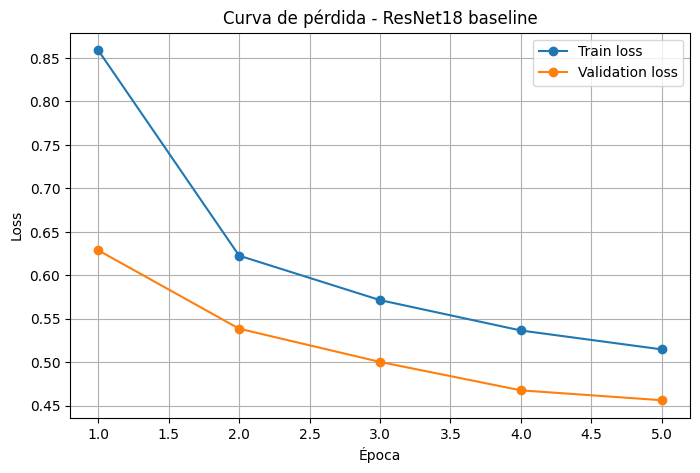

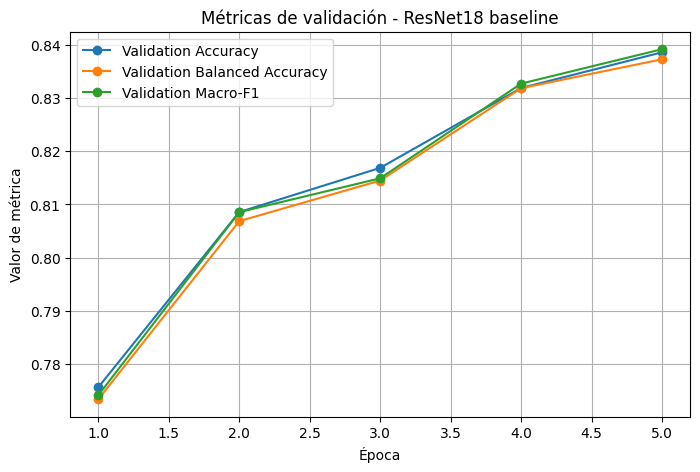

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], marker="o", label="Validation Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro-F1")
plt.xlabel("Época")
plt.ylabel("Valor de métrica")
plt.title("Métricas de validación - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

#12.- Evaluación final en test

Este bloque carga el mejor modelo encontrado durante validación y lo evalúa una sola vez sobre test.

Esto es importante metodológicamente: test no se usa para tomar decisiones, solo para reportar el rendimiento final.

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

test_results_df = pd.DataFrame([{
    "test_loss": test_loss,
    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_weighted_f1": test_metrics["weighted_f1"]
}])

display(test_results_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluando:   0%|          | 0/29 [00:00<?, ?it/s]

,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,0.556733,0.803621,0.764292,0.757633,0.807077


#13.- Reporte por clase

Este bloque muestra precision, recall y F1-score por cada clase. Es más informativo que mirar solo accuracy.

Para la presentación, de aquí puedes sacar qué clases reconoce mejor la CNN y en cuáles se equivoca más.

In [ ]:
report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                      precision    recall  f1-score   support

                             adipose     0.9407    0.9611    0.9508      1338
                          background     0.8982    1.0000    0.9464       847
                              debris     0.4426    0.6932    0.5402       339
                         lymphocytes     0.9240    0.8249    0.8717       634
                               mucus     0.9261    0.7140    0.8063      1035
                       smooth muscle     0.6409    0.7145    0.6757       592
                 normal colon mucosa     0.9041    0.6613    0.7638       741
            cancer-associated stroma     0.4437    0.4774    0.4600       421
colorectal adenocarcinoma epithelium     0.7773    0.8321    0.8038      1233

                            accuracy                         0.8036      7180
                           macro avg     0.7664    0.7643    0.7576      7180
                        weighted avg     0.8229    0.8036    0

#14.- Matriz de confusión

Este bloque genera la matriz de confusión. Sirve para ver visualmente entre qué clases se confunde el modelo.

Este gráfico es muy útil para la presentación, porque conecta el resultado cuantitativo con el problema médico: tejidos visualmente parecidos pueden confundirse más.

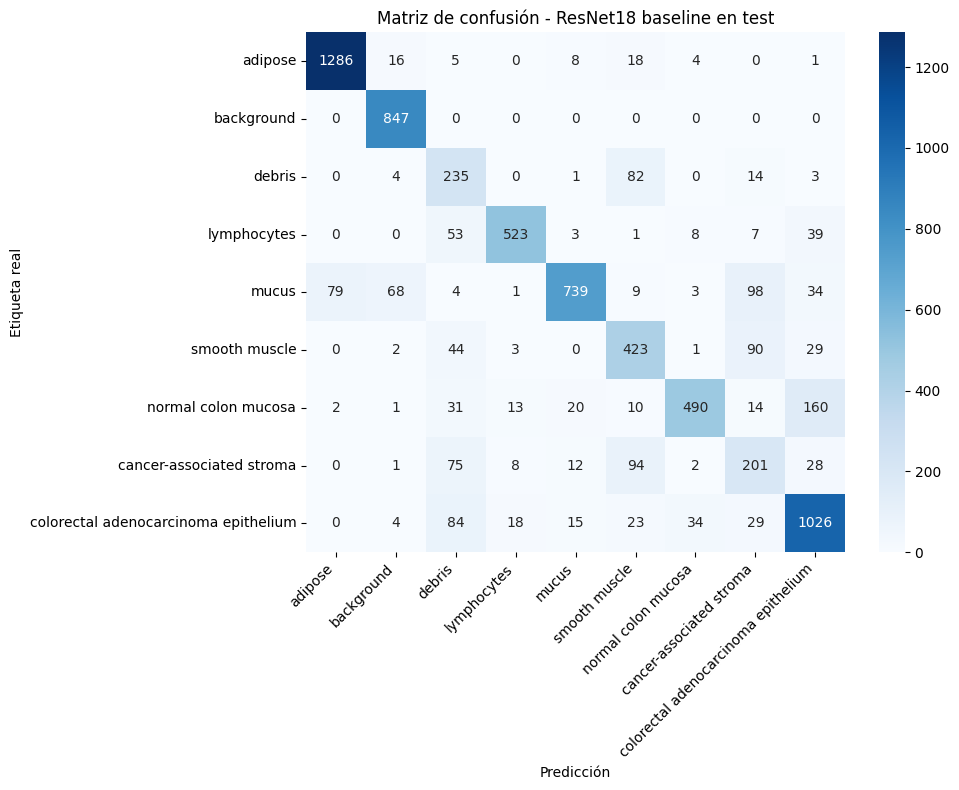

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - ResNet18 baseline en test")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 15.- Recapitulacion de los elementos utilizados.


In [ ]:
best_epoch = history_df.loc[history_df["val_macro_f1"].idxmax()]

summary_df = pd.DataFrame({
    "Elemento": [
        "Dataset",
        "Resolución",
        "Diseño experimental",
        "Modelo CNN baseline",
        "Fine-tuning",
        "Métrica principal 1",
        "Métrica principal 2",
        "Mejor época según validation",
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro-F1",
        "Test Weighted-F1"
    ],
    "Resultado": [
        "PathMNIST",
        "28x28 RGB",
        "Hold-out oficial: train / validation / test",
        "ResNet18 pre-entrenada",
        "Parcial: layer4 + fc entrenables",
        "Macro-F1",
        "Balanced Accuracy",
        int(best_epoch["epoch"]),
        round(test_metrics["accuracy"], 4),
        round(test_metrics["balanced_accuracy"], 4),
        round(test_metrics["macro_f1"], 4),
        round(test_metrics["weighted_f1"], 4)
    ]
})

display(summary_df)

,Elemento,Resultado
0,Dataset,PathMNIST
1,Resolución,28x28 RGB
2,Diseño experimental,Hold-out oficial: train / validation / test
3,Modelo CNN baseline,ResNet18 pre-entrenada
4,Fine-tuning,Parcial: layer4 + fc entrenables
5,Métrica principal 1,Macro-F1
6,Métrica principal 2,Balanced Accuracy
7,Mejor época según validation,5
8,Test Accuracy,0.8036
9,Test Balanced Accuracy,0.7643
